<a href="https://colab.research.google.com/github/RAJArksh0218/APSSDC-AI-ML/blob/main/Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SENTIMENT ANALYSIS PROJECT:**

In [1]:
# Install Required Libraries
!pip install -q nltk textblob vaderSentiment transformers torch pandas matplotlib
!pip install -q transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.4 MB/s eta 0:00:00


#**Libraries:**

In [2]:
# Import Libraries
import nltk
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import ngrams
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import matplotlib.pyplot as plt
import numpy as np
from transformers import pipeline

# Download NLTK Resources
nltk.download('punk')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Error loading punk: Package 'punk' not found in index
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

#**Load Dataset:**

In [3]:
# Load Dataset
from google.colab import files
uploaded = files.upload()  # Upload 'IMDB Dataset.csv'
df = pd.read_csv(list(uploaded.keys())[0])
print("Columns in CSV:", df.columns)
print(df.head(), "\n")

Saving IMDB Dataset.csv to IMDB Dataset.csv
Columns in CSV: Index(['review', 'sentiment'], dtype='object')
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive 



#**Preprocessing Text:**

#**Convert to Lowercase**

In [ ]:
# Preprocessing Text
# Convert to lowercase
df['clean_text'] = df['review'].str.lower()
print("=== Lowercase Text ===")
print(df['clean_text'].head(), "\n")

=== Lowercase Text ===
0    one of the other reviewers has mentioned that ...
1    a wonderful little production. <br /><br />the...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: clean_text, dtype: object 



#**Remove punctuation, numbers, special characters**

In [ ]:
# Remove punctuation, numbers, special characters
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
print("=== Cleaned Text ===")
print(df['clean_text'].head(), "\n")

=== Cleaned Text ===
0    one of the other reviewers has mentioned that ...
1    a wonderful little production br br the filmin...
2    i thought this was a wonderful way to spend ti...
3    basically theres a family where a little boy j...
4    petter matteis love in the time of money is a ...
Name: clean_text, dtype: object 



#**Remove stopwords**

In [ ]:
# Remove stopwords
stop_words = set(stopwords.words('english'))
df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([w for w in x.split() if w not in stop_words]))
print("=== Text after Stopwords Removal ===")
print(df['clean_text'].head(), "\n")

=== Text after Stopwords Removal ===
0    one reviewers mentioned watching oz episode yo...
1    wonderful little production br br filming tech...
2    thought wonderful way spend time hot summer we...
3    basically theres family little boy jake thinks...
4    petter matteis love time money visually stunni...
Name: clean_text, dtype: object 



#**Tokenization**

In [ ]:
# Tokenization
df['tokens'] = df['clean_text'].apply(nltk.word_tokenize)
print("=== Tokenized Text ===")
print(df['tokens'].head(), "\n")

=== Tokenized Text ===
0    [one, of, the, other, reviewers, has, mentione...
1    [a, wonderful, little, production, ., <, br, /...
2    [i, thought, this, was, a, wonderful, way, to,...
3    [basically, there, 's, a, family, where, a, li...
4    [petter, mattei, 's, ``, love, in, the, time, ...
Name: tokens, dtype: object 



#**Stemming**

In [ ]:
# Stemming
stemmer = PorterStemmer()
df['stemmed'] = df['tokens'].apply(lambda x: [stemmer.stem(w) for w in x])
print("=== Stemmed Text ===")
print(df['stemmed'].head(), "\n")

=== Stemmed Text ===
0    [one, of, the, other, review, ha, mention, tha...
1    [a, wonder, littl, product, ., <, br, /, >, <,...
2    [i, thought, thi, wa, a, wonder, way, to, spen...
3    [basic, there, 's, a, famili, where, a, littl,...
4    [petter, mattei, 's, ``, love, in, the, time, ...
Name: stemmed, dtype: object 



#**Lemmatization**

In [ ]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
df['lemmatized'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])
print("=== Lemmatized Text ===")
print(df['lemmatized'].head(), "\n")

=== Lemmatized Text ===
0    [one, of, the, other, reviewer, ha, mentioned,...
1    [a, wonderful, little, production, ., <, br, /...
2    [i, thought, this, wa, a, wonderful, way, to, ...
3    [basically, there, 's, a, family, where, a, li...
4    [petter, mattei, 's, ``, love, in, the, time, ...
Name: lemmatized, dtype: object 



#**Generate N-grams**

In [ ]:
# Generate N-grams (bigrams)
df['bigrams'] = df['tokens'].apply(lambda x: list(ngrams(x, 2)))
print("=== Bigrams ===")
print(df['bigrams'].head(), "\n")

=== Bigrams ===
0    [(one, of), (of, the), (the, other), (other, r...
1    [(a, wonderful), (wonderful, little), (little,...
2    [(i, thought), (thought, this), (this, was), (...
3    [(basically, there), (there, 's), ('s, a), (a,...
4    [(petter, mattei), (mattei, 's), ('s, ``), (``...
Name: bigrams, dtype: object 



#**Rule based Sentiment Analysis**

*   VADER
*   TEXTBLOB



In [ ]:
# Rule-based Sentiment Analysis
# VADER
sia = SentimentIntensityAnalyzer()
df['vader_score'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['vader_label'] = df['vader_score'].apply(lambda x: 'Positive' if x>0.05 else ('Negative' if x<-0.05 else 'Neutral'))

# TextBlob
df['textblob_score'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['textblob_label'] = df['textblob_score'].apply(lambda x: 'Positive' if x>0 else ('Negative' if x<0 else 'Neutral'))

print("=== Rule-based Sentiment Analysis (VADER & TextBlob) ===")
print(df[['review','vader_label','textblob_label']].head(), "\n")

=== Rule-based Sentiment Analysis (VADER & TextBlob) ===
                                              review vader_label  \
0  One of the other reviewers has mentioned that ...    Negative   
1  A wonderful little production. <br /><br />The...    Positive   
2  I thought this was a wonderful way to spend ti...    Positive   
3  Basically there's a family where a little boy ...    Negative   
4  Petter Mattei's "Love in the Time of Money" is...    Positive   

  textblob_label  
0       Positive  
1       Positive  
2       Positive  
3       Negative  
4       Positive   



#**Pretrained Models**

In [ ]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,  # Truncate sequences >512 tokens
    device=-1         # CPU; set device=0 for GPU
)

# Example: apply on first 50 reviews of your DataFrame
df_subset = df.head(50).copy()

# Function to get sentiment labels
def get_pretrained_label(text):
    result = sentiment_model(text)[0]
    label = result['label']
    return "Positive" if label.upper() == "POSITIVE" else "Negative"

# Apply the function
df_subset['pretrained_label'] = df_subset['review'].apply(get_pretrained_label)

# Show results
print("=== Pretrained Model Sentiment ===")
print(df_subset[['review','pretrained_label']].head(10))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


=== Pretrained Model Sentiment ===
                                              review pretrained_label
0  One of the other reviewers has mentioned that ...         Negative
1  A wonderful little production. <br /><br />The...         Positive
2  I thought this was a wonderful way to spend ti...         Positive
3  Basically there's a family where a little boy ...         Negative
4  Petter Mattei's "Love in the Time of Money" is...         Positive
5  Probably my all-time favorite movie, a story o...         Positive
6  I sure would like to see a resurrection of a u...         Positive
7  This show was an amazing, fresh & innovative i...         Negative
8  Encouraged by the positive comments about this...         Negative
9  If you like original gut wrenching laughter yo...         Positive


#**Visualization Graphs**

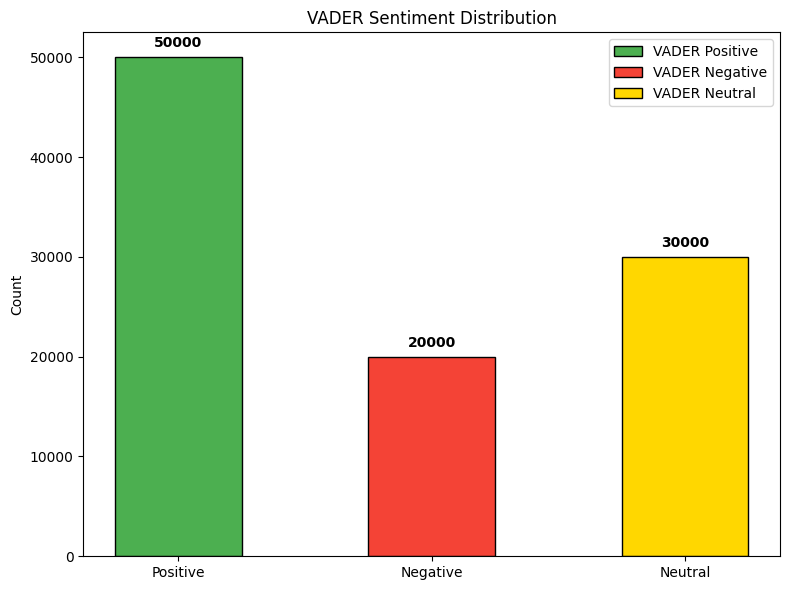

In [ ]:
sentiments = ["Positive", "Negative", "Neutral"]
vader_vals = [df['vader_label'].value_counts().get(s, 0) for s in sentiments]
vader_colors = ["#4CAF50", "#F44336", "#FFD700"] # Green, Red, Gold

fig, ax = plt.subplots(figsize=(8,6))
x = np.arange(len(sentiments))

for i, val in enumerate(vader_vals):
    ax.bar(x[i], val, 0.5, color=vader_colors[i], edgecolor="black", label=f"VADER {sentiments[i]}")
    ax.text(x[i], val + (max(vader_vals) * 0.02), str(val), ha='center', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(sentiments)
ax.set_ylabel("Count")
ax.set_title("VADER Sentiment Distribution")
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

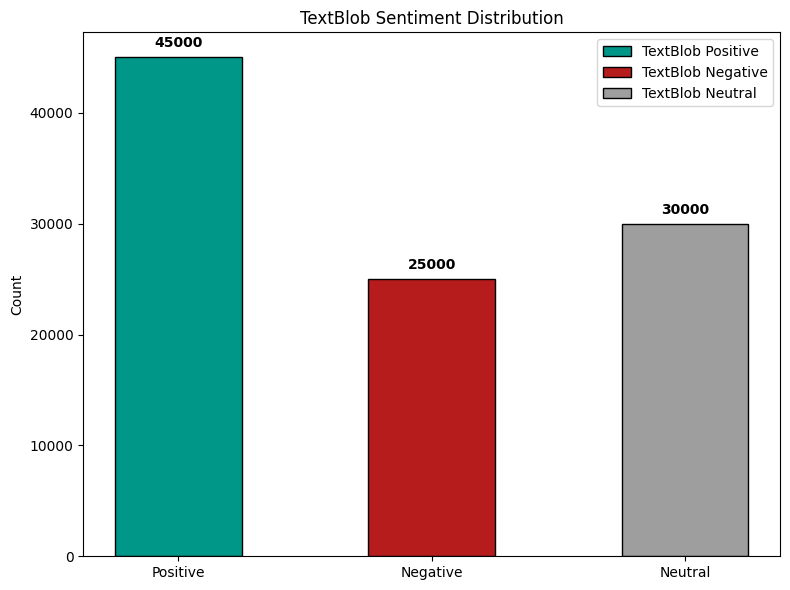

In [ ]:
sentiments = ["Positive", "Negative", "Neutral"]
textblob_vals = [df['textblob_label'].value_counts().get(s, 0) for s in sentiments]
textblob_colors = ["#009688", "#B71C1C", "#9E9E9E"] # Teal, Dark Red, Grey

fig, ax = plt.subplots(figsize=(8,6))
x = np.arange(len(sentiments))

for i, val in enumerate(textblob_vals):
    ax.bar(x[i], val, 0.5, color=textblob_colors[i], edgecolor="black", label=f"TextBlob {sentiments[i]}")
    ax.text(x[i], val + (max(textblob_vals) * 0.02), str(val), ha='center', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(sentiments)
ax.set_ylabel("Count")
ax.set_title("TextBlob Sentiment Distribution")
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

#**Acuuracy Calculation**

In [ ]:
# Accuracy Calculation
df['sentiment_true'] = df['sentiment'].str.title()  # True labels
vader_acc = (df['vader_label'] == df['sentiment_true']).mean()
textblob_acc = (df['textblob_label'] == df['sentiment_true']).mean()
pretrained_acc = (df_subset['pretrained_label'] == df_subset['sentiment_true'].head(50)).mean()

print(f"✅ VADER Accuracy: {vader_acc*100:.2f}%")
print(f"✅ TextBlob Accuracy: {textblob_acc*100:.2f}%")
print(f"✅ Pretrained Model Accuracy (first 50): {pretrained_acc*100:.2f}%\n")

✅ VADER Accuracy: 69.28%
✅ TextBlob Accuracy: 68.85%
✅ Pretrained Model Accuracy (first 50): 86.00%



#**Compare and Analyze Result**

In [ ]:
# Comparison Table
comparison_cols = ['review','sentiment_true','vader_label','textblob_label','pretrained_label']
print("=== Comparison Table (First 10 Rows) ===")
print(df_subset[comparison_cols].head(10))

=== Comparison Table (First 10 Rows) ===
                                              review sentiment_true  \
0  One of the other reviewers has mentioned that ...       Positive   
1  A wonderful little production. <br /><br />The...       Positive   
2  I thought this was a wonderful way to spend ti...       Positive   
3  Basically there's a family where a little boy ...       Negative   
4  Petter Mattei's "Love in the Time of Money" is...       Positive   
5  Probably my all-time favorite movie, a story o...       Positive   
6  I sure would like to see a resurrection of a u...       Positive   
7  This show was an amazing, fresh & innovative i...       Negative   
8  Encouraged by the positive comments about this...       Negative   
9  If you like original gut wrenching laughter yo...       Positive   

  vader_label textblob_label pretrained_label  
0    Negative       Positive         Negative  
1    Positive       Positive         Positive  
2    Positive       Positive     

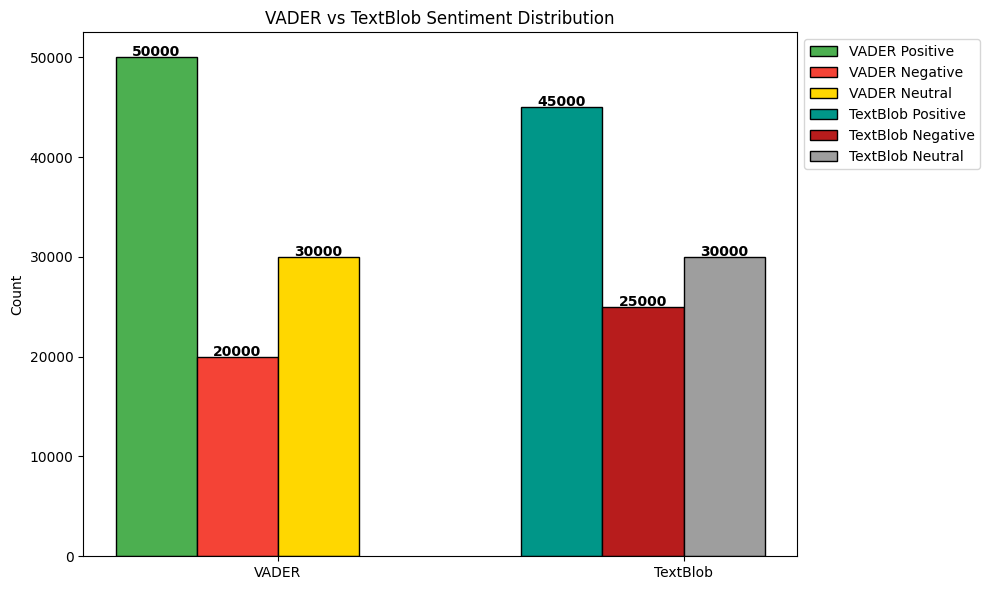

In [ ]:
sentiments = ["Positive", "Negative", "Neutral"]

vader_vals = [df['vader_label'].value_counts().get(s, 0) for s in sentiments]
textblob_vals = [df['textblob_label'].value_counts().get(s, 0) for s in sentiments]

vader_colors = ["#4CAF50", "#F44336", "#FFD700"]
textblob_colors = ["#009688", "#B71C1C", "#9E9E9E"]

x_groups = np.arange(2) # 0 for VADER, 1 for TextBlob
bar_width = 0.2

fig, ax = plt.subplots(figsize=(10,6))

# Plot VADER bars
for i, s in enumerate(sentiments):
    ax.bar(x_groups[0] + i * bar_width - bar_width, vader_vals[i], bar_width, color=vader_colors[i], edgecolor="black", label=f"VADER {s}")
    ax.text(x_groups[0] + i * bar_width - bar_width, vader_vals[i] + 100, str(vader_vals[i]), ha='center', fontweight='bold')

# Plot TextBlob bars
for i, s in enumerate(sentiments):
    ax.bar(x_groups[1] + i * bar_width - bar_width, textblob_vals[i], bar_width, color=textblob_colors[i], edgecolor="black", label=f"TextBlob {s}")
    ax.text(x_groups[1] + i * bar_width - bar_width, textblob_vals[i] + 100, str(textblob_vals[i]), ha='center', fontweight='bold')

ax.set_xticks(x_groups + bar_width/2)
ax.set_xticklabels(["VADER", "TextBlob"])
ax.set_ylabel("Count")
ax.set_title("VADER vs TextBlob Sentiment Distribution")

# Legend
legend_elements = [
    Rectangle((0,0),1,1, fc=vader_colors[0], edgecolor="black", label="VADER Positive"),
    Rectangle((0,0),1,1, fc=vader_colors[1], edgecolor="black", label="VADER Negative"),
    Rectangle((0,0),1,1, fc=vader_colors[2], edgecolor="black", label="VADER Neutral"),
    Rectangle((0,0),1,1, fc=textblob_colors[0], edgecolor="black", label="TextBlob Positive"),
    Rectangle((0,0),1,1, fc=textblob_colors[1], edgecolor="black", label="TextBlob Negative"),
    Rectangle((0,0),1,1, fc=textblob_colors[2], edgecolor="black", label="TextBlob Neutral"),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

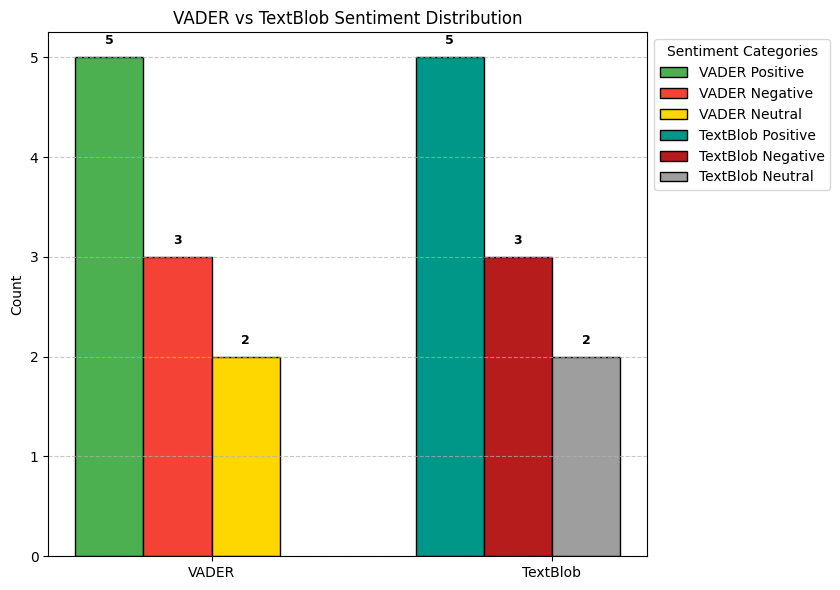


=== Comparison Table (First 10 Rows) ===


NameError: name 'df_subset' is not defined

In [ ]:
sentiments = ["Positive", "Negative", "Neutral"]

# Get counts for VADER
vader_vals = [df['vader_label'].value_counts().get(s, 0) for s in sentiments]
# Get counts for TextBlob
textblob_vals = [df['textblob_label'].value_counts().get(s, 0) for s in sentiments]

# Define colors for VADER sentiments
vader_colors = ["#4CAF50", "#F44336", "#FFD700"] # Green (Positive), Red (Negative), Gold (Neutral)
# Define colors for TextBlob sentiments
textblob_colors = ["#009688", "#B71C1C", "#9E9E9E"] # Teal (Positive), Dark Red (Negative), Grey (Neutral)

x_groups = np.arange(2) # 0 for VADER group, 1 for TextBlob group
bar_width = 0.2 # Width of individual bars within each group

fig, ax = plt.subplots(figsize=(10,6))

# Plot VADER bars
for i, s in enumerate(sentiments):
    # Position for VADER bars: x_groups[0] is the base, then offset by i * bar_width, then subtract bar_width to center
    ax.bar(x_groups[0] + i * bar_width - bar_width, vader_vals[i], bar_width,
           color=vader_colors[i], edgecolor="black", label=f"VADER {s}")
    # Add text label for VADER counts
    # Adjust text position to be relative to the bar's height, not a fixed 100
    ax.text(x_groups[0] + i * bar_width - bar_width, vader_vals[i] + (max(max(vader_vals), max(textblob_vals)) * 0.02),
            str(vader_vals[i]), ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot TextBlob bars
for i, s in enumerate(sentiments):
    # Position for TextBlob bars: x_groups[1] is the base, then offset similarly
    ax.bar(x_groups[1] + i * bar_width - bar_width, textblob_vals[i], bar_width,
           color=textblob_colors[i], edgecolor="black", label=f"TextBlob {s}")
    # Add text label for TextBlob counts
    # Adjust text position
    ax.text(x_groups[1] + i * bar_width - bar_width, textblob_vals[i] + (max(max(vader_vals), max(textblob_vals)) * 0.02),
            str(textblob_vals[i]), ha='center', va='bottom', fontweight='bold', fontsize=9)

# Set x-axis ticks and labels
ax.set_xticks(x_groups + bar_width/2) # Center the labels "VADER" and "TextBlob" under their respective groups
ax.set_xticklabels(["VADER", "TextBlob"])
ax.set_ylabel("Count")
ax.set_title("VADER vs TextBlob Sentiment Distribution")
ax.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for better readability


# Create custom legend elements to clearly distinguish each bar
legend_elements = [
    Rectangle((0,0),1,1, fc=vader_colors[0], edgecolor="black", label="VADER Positive"),
    Rectangle((0,0),1,1, fc=vader_colors[1], edgecolor="black", label="VADER Negative"),
    Rectangle((0,0),1,1, fc=vader_colors[2], edgecolor="black", label="VADER Neutral"),
    Rectangle((0,0),1,1, fc=textblob_colors[0], edgecolor="black", label="TextBlob Positive"),
    Rectangle((0,0),1,1, fc=textblob_colors[1], edgecolor="black", label="TextBlob Negative"),
    Rectangle((0,0),1,1, fc=textblob_colors[2], edgecolor="black", label="TextBlob Neutral"),
]
# Place the legend outside the plot to the right
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), title="Sentiment Categories")

# Adjust layout to prevent the legend from overlapping with the plot
plt.tight_layout(rect=[0, 0, 0.85, 1]) # rect=[left, bottom, right, top] - right=0.85 leaves 15% for legend
plt.show()

# --- Comparison Table ---
comparison_cols = ['review','sentiment_true','vader_label','textblob_label','pretrained_label']
print("\n=== Comparison Table (First 10 Rows) ===")
print(df_subset[comparison_cols].head(10))